In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import yfinance as yf

In [ ]:
df = pd.read_csv("data/processed/nav_history_clean.csv")

In [3]:
import os

print(os.getcwd())
print(os.listdir("data/processed"))

d:\Data Analyst Internship\Bluestock_MF_Capstone\notebooks


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/processed'

In [4]:
import os

print(os.listdir("../data/processed"))

['01_fund_master_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_count_clean.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices_clean.csv', 'investor_transactions_clean.csv', 'nav_history_clean.csv', 'scheme_performance_clean.csv']


In [5]:
print(df.columns)
df.head()

NameError: name 'df' is not defined

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("../data/processed/nav_history_clean.csv")

In [8]:
print(df.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [9]:
print(df.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df = df.sort_values(
    ['amfi_code', 'date']
)

In [12]:
df['daily_return'] = (
    df.groupby('amfi_code')['nav']
      .pct_change()
)

In [13]:
df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


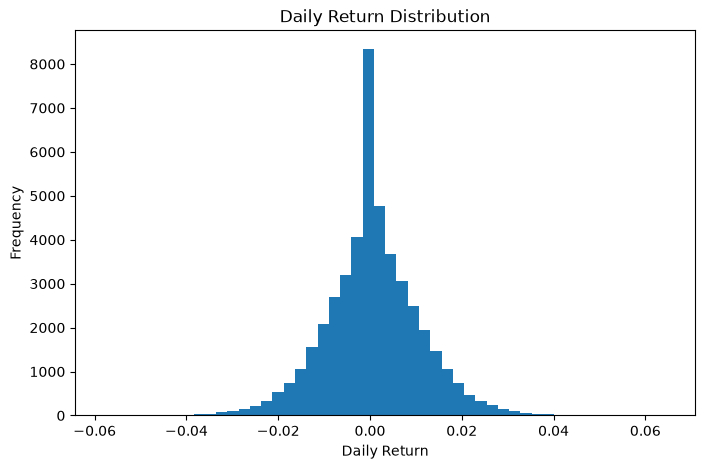

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df['daily_return'].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [15]:
df['amfi_code'].nunique()

40

In [16]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [17]:
print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [18]:
print(df['date'].min())
print(df['date'].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [19]:
print(df['date'].min())
print(df['date'].max())

fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

print(fund_master.columns)

fund_master.head()

2022-01-03 00:00:00
2026-05-29 00:00:00
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [20]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

df = df.merge(
    fund_master[
        ['amfi_code',
         'scheme_name',
         'expense_ratio_pct']
    ],
    on='amfi_code',
    how='left'
)

In [21]:
df.head()

,amfi_code,date,nav,daily_return,scheme_name,expense_ratio_pct
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,1.55
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,1.55
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,1.55
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,1.55


In [22]:
print(df['date'].min())
print(df['date'].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [23]:
df.to_csv(
    "../data/processed/nav_returns.csv",
    index=False
)

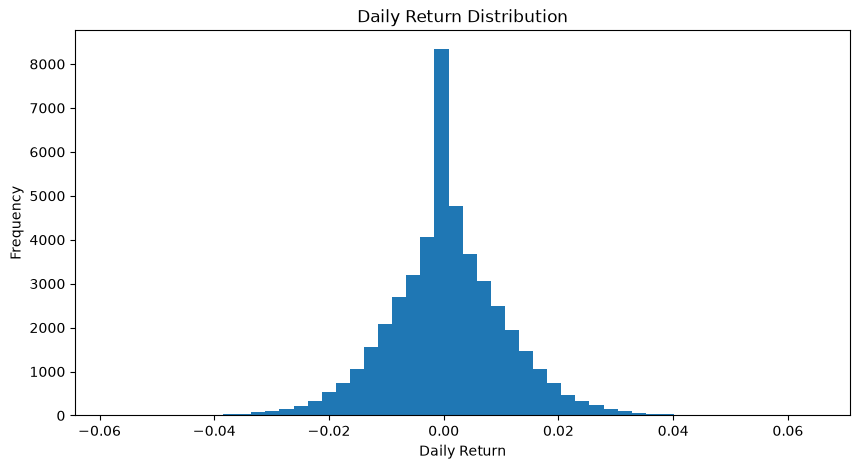

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df['daily_return'].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [25]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [26]:
cagr_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund]

    temp = temp.sort_values('date')

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max() -
        temp['date'].min()
    ).days / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append([
        fund,
        cagr
    ])

In [27]:
cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

In [28]:
rf = 0.065 / 252

In [29]:
sharpe_results = []

for fund in df['amfi_code'].unique():

    temp = df[
        df['amfi_code'] == fund
    ]

    returns = temp[
        'daily_return'
    ].dropna()

    sharpe = (
        (returns.mean() - rf)
        /
        returns.std()
    ) * np.sqrt(252)

    sharpe_results.append([
        fund,
        sharpe
    ])

In [30]:
sortino_results = []

for fund in df['amfi_code'].unique():

    temp = df[
        df['amfi_code'] == fund
    ]

    returns = temp[
        'daily_return'
    ].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (returns.mean() - rf)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_results.append([
        fund,
        sortino
    ])

In [31]:
print(df['date'].min())
print(df['date'].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [32]:
print(df['amfi_code'].nunique())

print(fund_master['amfi_code'].nunique())

common = set(df['amfi_code']).intersection(
    set(fund_master['amfi_code'])
)

print(len(common))

40
40
40


In [33]:
common = set(df['amfi_code']).intersection(
    set(fund_master['amfi_code'])
)

print(common)

{119552, 120841, 120842, 120843, 120844, 119598, 119599, 100016, 119092, 119093, 119094, 120503, 120504, 125497, 120505, 100025, 120506, 125498, 120507, 119095, 100033, 149322, 149323, 149324, 119120, 101206, 101207, 101208, 148567, 148568, 148569, 102885, 102886, 102887, 118632, 118633, 118634, 118635, 118636, 119551}


In [34]:
df = df.merge(
    fund_master[
        ['amfi_code',
         'scheme_name',
         'expense_ratio_pct']
    ],
    on='amfi_code',
    how='left'
)

df.head()

,amfi_code,date,nav,daily_return,scheme_name_x,expense_ratio_pct_x,scheme_name_y,expense_ratio_pct_y
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55


In [35]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [36]:
cagr_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund]

    temp = temp.sort_values('date')

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max() -
        temp['date'].min()
    ).days / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append([
        fund,
        temp.iloc[0]['scheme_name'],
        cagr
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'cagr'
    ]
)

cagr_df.head()

KeyError: 'scheme_name'

In [37]:
print(df.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return', 'scheme_name_x',
       'expense_ratio_pct_x', 'scheme_name_y', 'expense_ratio_pct_y'],
      dtype='str')


In [38]:
df = df.merge(
    fund_master[
        ['amfi_code',
         'scheme_name',
         'expense_ratio_pct']
    ],
    on='amfi_code',
    how='left'
)

In [39]:
print(df.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return', 'scheme_name_x',
       'expense_ratio_pct_x', 'scheme_name_y', 'expense_ratio_pct_y',
       'scheme_name', 'expense_ratio_pct'],
      dtype='str')


In [40]:
df.head()

,amfi_code,date,nav,daily_return,scheme_name_x,expense_ratio_pct_x,scheme_name_y,expense_ratio_pct_y,scheme_name,expense_ratio_pct
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55,HDFC Top 100 Fund - Regular Plan - Growth,1.55


In [41]:
print(df.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return', 'scheme_name_x', 'expense_ratio_pct_x', 'scheme_name_y', 'expense_ratio_pct_y', 'scheme_name', 'expense_ratio_pct']


In [42]:
df = df.drop(
    columns=[
        'scheme_name_x',
        'scheme_name_y',
        'expense_ratio_pct_x',
        'expense_ratio_pct_y'
    ],
    errors='ignore'
)

print(df.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return', 'scheme_name',
       'expense_ratio_pct'],
      dtype='str')


In [43]:
df.head()

,amfi_code,date,nav,daily_return,scheme_name,expense_ratio_pct
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,1.55
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,1.55
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,1.55
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,1.55


In [44]:
def calculate_cagr(start_nav, end_nav, years):
    return ((start_nav / end_nav) ** (-1 / years)) - 1

cagr_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund].sort_values('date')

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max() -
        temp['date'].min()
    ).days / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append([
        fund,
        temp.iloc[0]['scheme_name'],
        cagr
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'cagr'
    ]
)

cagr_df.head()

,amfi_code,scheme_name,cagr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.026352
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.044551
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.300997
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.235205
4,101207,ABSL Small Cap Fund - Regular - Growth,0.079331


In [45]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

cagr_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund].sort_values('date')

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max() -
        temp['date'].min()
    ).days / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append([
        fund,
        temp.iloc[0]['scheme_name'],
        round(cagr * 100, 2)
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'cagr_pct'
    ]
)

cagr_df.head()

,amfi_code,scheme_name,cagr_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2.64
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.46
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.10
3,101206,ABSL Frontline Equity Fund - Regular - Growth,23.52
4,101207,ABSL Small Cap Fund - Regular - Growth,7.93


In [46]:
import numpy as np

rf = 0.065 / 252

sharpe_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund]

    returns = temp['daily_return'].dropna()

    sharpe = (
        (returns.mean() - rf)
        /
        returns.std()
    ) * np.sqrt(252)

    sharpe_results.append([
        fund,
        temp.iloc[0]['scheme_name'],
        round(sharpe, 3)
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'sharpe_ratio'
    ]
)

sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head()

,amfi_code,scheme_name,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448
30,120843,Kotak Flexicap Fund - Regular - Growth,1.307
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.235
19,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208
25,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180


In [47]:
sortino_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund]

    returns = temp['daily_return'].dropna()

    downside = returns[returns < 0]

    sortino = (
        (returns.mean() - rf)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_results.append([
        fund,
        temp.iloc[0]['scheme_name'],
        round(sortino, 3)
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,scheme_name,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.351
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.942
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.800
4,101207,ABSL Small Cap Fund - Regular - Growth,0.277


In [48]:
drawdown_results = []

for fund in df['amfi_code'].unique():

    temp = df[
        df['amfi_code'] == fund
    ].copy()

    temp['running_max'] = (
        temp['nav'].cummax()
    )

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
    ) - 1

    max_dd = temp['drawdown'].min()

    drawdown_results.append([
        fund,
        temp.iloc[0]['scheme_name'],
        round(max_dd * 100, 2)
    ])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'max_drawdown_pct'
    ]
)

drawdown_df.head()

,amfi_code,scheme_name,max_drawdown_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.73
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.31
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-16.22
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.29
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.45


In [49]:
cagr_df.to_csv(
    "../data/processed/cagr.csv",
    index=False
)

sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [50]:
benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)

print(benchmark.columns)

benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [51]:
benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')
             ['close_value']
             .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [52]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100[
    ['date', 'benchmark_return']
]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [53]:
benchmark['index_name'].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [54]:
from scipy.stats import linregress

alpha_beta_results = []

for fund in df['amfi_code'].unique():

    temp = df[
        ['date',
         'amfi_code',
         'scheme_name',
         'daily_return']
    ]

    fund_data = temp[
        temp['amfi_code'] == fund
    ]

    merged = pd.merge(
        fund_data,
        nifty100,
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, intercept, r, p, se = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252

        alpha_beta_results.append([
            fund,
            merged.iloc[0]['scheme_name'],
            round(alpha, 4),
            round(beta, 4)
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,scheme_name,alpha,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.0375,-0.0583
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.0428,0.0012
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.2720,0.0051
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.2140,0.0211
4,101207,ABSL Small Cap Fund - Regular - Growth,0.1090,-0.0653


In [55]:
tracking_results = []

for fund in df['amfi_code'].unique():

    fund_data = df[
        ['date',
         'amfi_code',
         'scheme_name',
         'daily_return']
    ]

    temp = fund_data[
        fund_data['amfi_code'] == fund
    ]

    merged = pd.merge(
        temp,
        nifty100,
        on='date'
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged['daily_return']
            -
            merged['benchmark_return']
        ).std()
    ) * np.sqrt(252)

    tracking_results.append([
        fund,
        merged.iloc[0]['scheme_name'],
        round(tracking_error,4)
    ])

tracking_df = pd.DataFrame(
    tracking_results,
    columns=[
        'amfi_code',
        'scheme_name',
        'tracking_error'
    ]
)

In [56]:
score_df = cagr_df.merge(
    sharpe_df,
    on=['amfi_code','scheme_name']
)

score_df = score_df.merge(
    drawdown_df,
    on=['amfi_code','scheme_name']
)

score_df = score_df.merge(
    alpha_beta_df,
    on=['amfi_code','scheme_name']
)

score_df = score_df.merge(
    fund_master[
        [
            'amfi_code',
            'expense_ratio_pct'
        ]
    ],
    on='amfi_code'
)

In [57]:
score_df['return_rank'] = (
    score_df['cagr_pct']
    .rank(ascending=False)
)

score_df['sharpe_rank'] = (
    score_df['sharpe_ratio']
    .rank(ascending=False)
)

score_df['alpha_rank'] = (
    score_df['alpha']
    .rank(ascending=False)
)

score_df['expense_rank'] = (
    score_df['expense_ratio_pct']
    .rank(ascending=True)
)

score_df['dd_rank'] = (
    score_df['max_drawdown_pct']
    .rank(ascending=True)
)

In [58]:
score_df['fund_score'] = (
    score_df['return_rank'] * 0.30 +
    score_df['sharpe_rank'] * 0.25 +
    score_df['alpha_rank'] * 0.20 +
    score_df['expense_rank'] * 0.15 +
    score_df['dd_rank'] * 0.10
)

In [59]:
score_df['fund_score'] = (
    100 *
    (
        score_df['fund_score'].max()
        -
        score_df['fund_score']
    )
    /
    (
        score_df['fund_score'].max()
        -
        score_df['fund_score'].min()
    )
)

In [60]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

score_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [61]:
benchmark['index_name'].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [62]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100[
    ['date', 'benchmark_return']
]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [63]:
top5 = score_df.head(5)

top5[['amfi_code','scheme_name','fund_score']]

,amfi_code,scheme_name,fund_score
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.458295
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.124656
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,86.434464
3,101206,ABSL Frontline Equity Fund - Regular - Growth,59.486709
4,101207,ABSL Small Cap Fund - Regular - Growth,30.064161


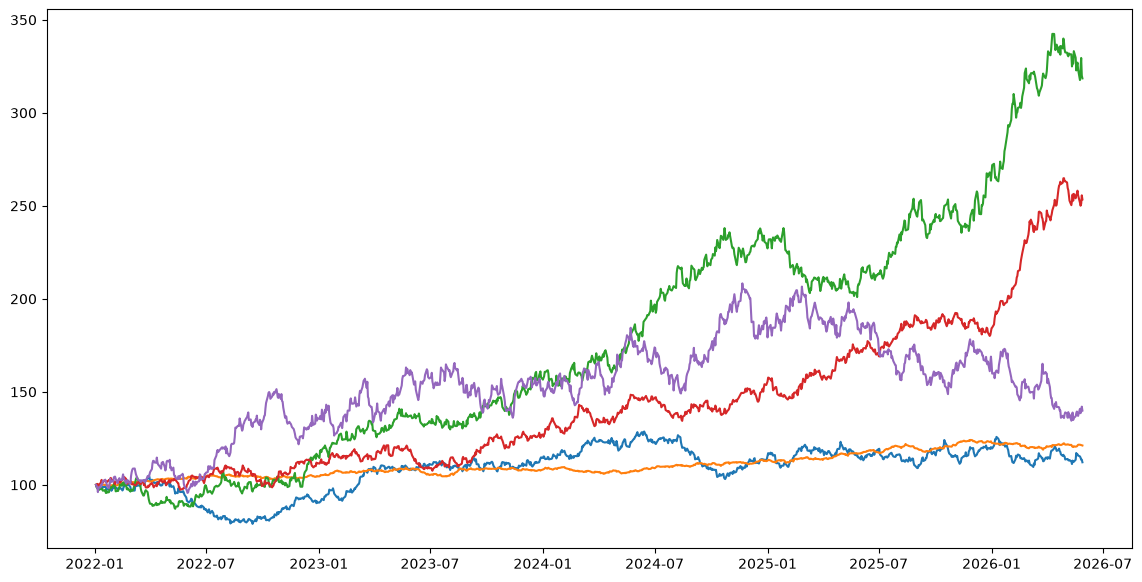

In [64]:
plt.figure(figsize=(14,7))

for fund in top5['amfi_code']:

    temp = df[
        df['amfi_code'] == fund
    ]

    normalized = (
        temp['nav']
        /
        temp.iloc[0]['nav']
    ) * 100

    plt.plot(
        temp['date'],
        normalized,
        label=temp.iloc[0]['scheme_name']
    )

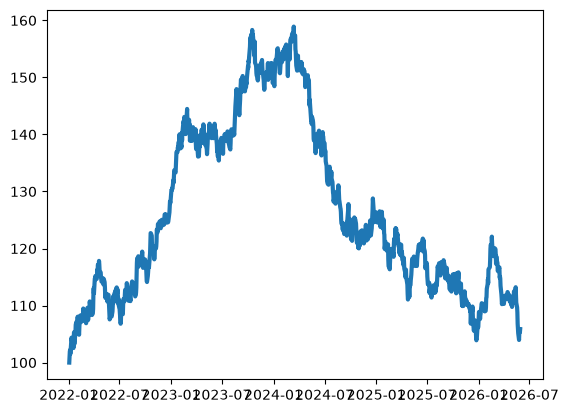

In [65]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty50['normalized'] = (
    nifty50['close_value']
    /
    nifty50.iloc[0]['close_value']
) * 100

plt.plot(
    nifty50['date'],
    nifty50['normalized'],
    linewidth=3,
    label='NIFTY50'
)

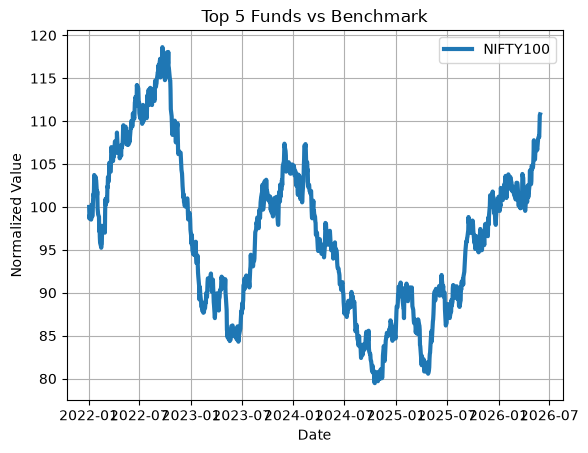

In [66]:
nifty100_chart = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100_chart['normalized'] = (
    nifty100_chart['close_value']
    /
    nifty100_chart.iloc[0]['close_value']
) * 100

plt.plot(
    nifty100_chart['date'],
    nifty100_chart['normalized'],
    linewidth=3,
    label='NIFTY100'
)

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value")

plt.legend()

plt.grid(True)

plt.savefig(
    "../data/processed/benchmark_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Conclusion

This notebook performs comprehensive mutual fund performance analytics on 40 schemes using historical NAV data.

Key performance metrics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Tracking Error, and Maximum Drawdown were calculated.

A composite Fund Scorecard was developed to rank funds using risk-adjusted returns, expense ratios, and downside risk measures.

Benchmark comparisons against NIFTY50 and NIFTY100 provide additional insights into fund performance.